In [1]:

!pip -q install scikit-image pandas seaborn

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim
from IPython.display import display

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# =========================
# 2. Configuration
# =========================
TRAIN_PER_DIGIT = 1000       # 10,000 training images
TEST_PER_DIGIT = 200         # 2,000 test images

BATCH_SIZE = 128
EPOCHS = 20

BASE_LATENT_DIM = 16
VAE_LATENT_DIM = 2

# Set True if you want to run every additional experiment.
RUN_ADDITIONAL_EXERCISES = True

# Training all additional experiments can take time.
# Set to False if you only need the main assignment.
RUN_FULL_ADDITIONAL_TRAINING = True

print("Configuration loaded.")

Configuration loaded.


In [3]:
# =========================
# 3. Load MNIST and create balanced subsets
# =========================
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

def balanced_subset(x, y, per_digit, seed=42):
    rng = np.random.default_rng(seed)
    selected = []
    for digit in range(10):
        idx = np.where(y == digit)[0]
        chosen = rng.choice(idx, size=per_digit, replace=False)
        selected.extend(chosen)
    selected = np.array(selected)
    rng.shuffle(selected)
    return x[selected], y[selected]

x_train, y_train = balanced_subset(x_train_full, y_train_full, TRAIN_PER_DIGIT, SEED)
x_test, y_test = balanced_subset(x_test_full, y_test_full, TEST_PER_DIGIT, SEED + 1)

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Training labels:", np.bincount(y_train))
print("Test labels:", np.bincount(y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (10000, 28, 28, 1)
Test shape: (2000, 28, 28, 1)
Training labels: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Test labels: [200 200 200 200 200 200 200 200 200 200]


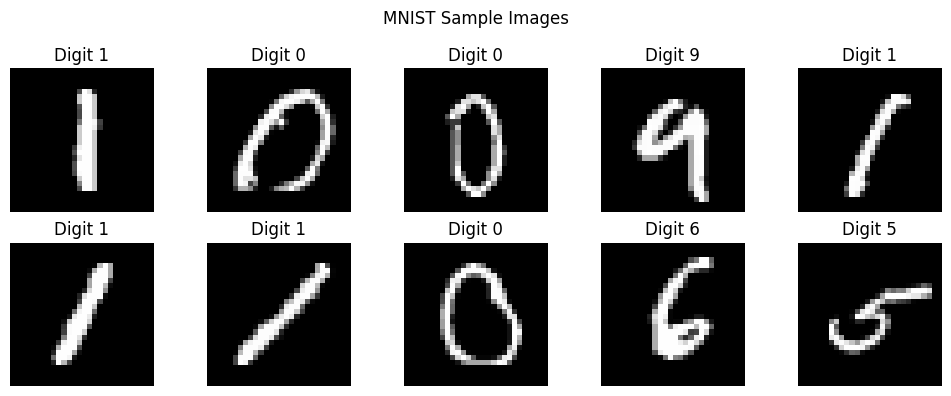

In [4]:
# =========================
# 4. Dataset visualization
# =========================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit {y_train[i]}")
    plt.axis("off")
plt.suptitle("MNIST Sample Images")
plt.tight_layout()
plt.show()

In [5]:
# =========================
# 5. Helper functions
# =========================
def calculate_metrics(original, reconstructed):
    original = np.asarray(original).squeeze()
    reconstructed = np.asarray(reconstructed).squeeze()

    mse = float(np.mean((original - reconstructed) ** 2))
    mae = float(np.mean(np.abs(original - reconstructed)))

    ssim_values = [
        ssim(original[i], reconstructed[i], data_range=1.0)
        for i in range(len(original))
    ]
    return mse, mae, float(np.mean(ssim_values))

def count_parameters(model):
    return int(model.count_params())

def plot_reconstructions(original, reconstructed, title, n=10):
    n = min(n, len(original))
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructed[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Reconstruction")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_history(history, title="Training and Validation Reconstruction Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def train_model(model, xtr, ytr=None, xval=None, yval=None, epochs=EPOCHS, batch_size=BATCH_SIZE):
    start = time.time()
    if ytr is None:
        history = model.fit(
            xtr, xtr,
            validation_data=(xval, xval) if xval is not None else None,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
    else:
        history = model.fit(
            xtr, ytr,
            validation_data=(xval, yval) if xval is not None else None,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )
    elapsed = time.time() - start
    return history, elapsed

def metrics_row(name, model, original, reconstructed, elapsed):
    mse, mae, ssim_value = calculate_metrics(original, reconstructed)
    return {
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value,
        "Parameters": count_parameters(model),
        "Time (s)": elapsed
    }

Model: "Fully_Connected_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.3464 - val_loss: 0.2518
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2265 - val_loss: 0.2062
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1928 - val_loss: 0.1824
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1730 - val_loss: 0.1651
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1608 - val_loss: 0.1571
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1547 - val_loss: 0.1523
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1503 - val_loss: 0.1484
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1464 - val_loss: 0.1450
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1425 - val_loss: 0.1413
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1392 - val_loss: 0.1383
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1364 - val_loss: 0.1357
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1341 - val

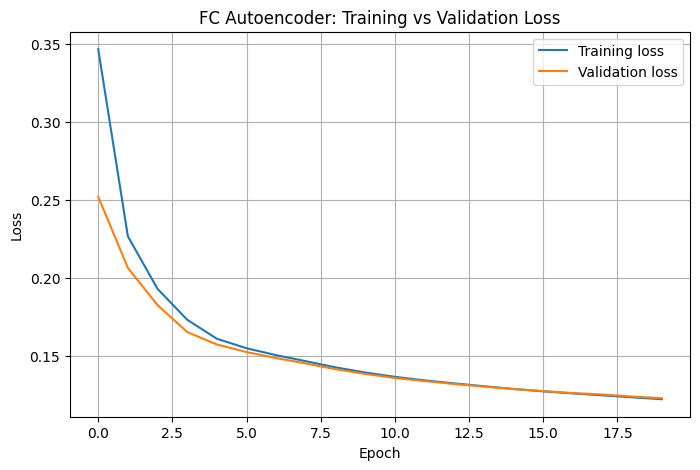

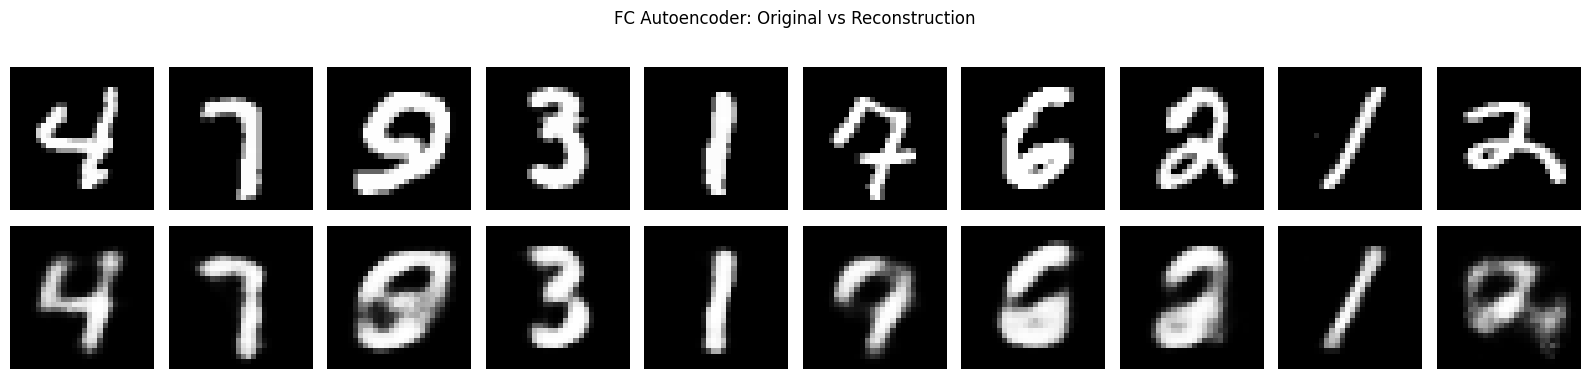

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Fully Connected AE,0.019749,0.054336,0.775095,211040,32.065709


In [6]:
# =========================
# 6. Fully Connected Autoencoder
# Architecture:
# 784 -> 128 -> 32 -> 16 -> 32 -> 128 -> 784
# =========================
def build_fc_autoencoder(latent_dim=16):
    inp = keras.Input(shape=(28, 28, 1), name="input_image")
    x = layers.Flatten()(inp)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    x = layers.Dense(32, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(784, activation="sigmoid")(x)
    out = layers.Reshape((28, 28, 1))(out)

    model = Model(inp, out, name="Fully_Connected_AE")
    encoder = Model(inp, z, name="FC_Encoder")
    return model, encoder

fc_ae, fc_encoder = build_fc_autoencoder(BASE_LATENT_DIM)
fc_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy")

fc_ae.summary()

fc_history, fc_time = train_model(fc_ae, x_train, xval=x_test, epochs=EPOCHS)

fc_recon = fc_ae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

plot_history(fc_history, "FC Autoencoder: Training vs Validation Loss")
plot_reconstructions(x_test, fc_recon, "FC Autoencoder: Original vs Reconstruction", 10)

fc_metrics = metrics_row("Fully Connected AE", fc_ae, x_test, fc_recon, fc_time)
pd.DataFrame([fc_metrics])

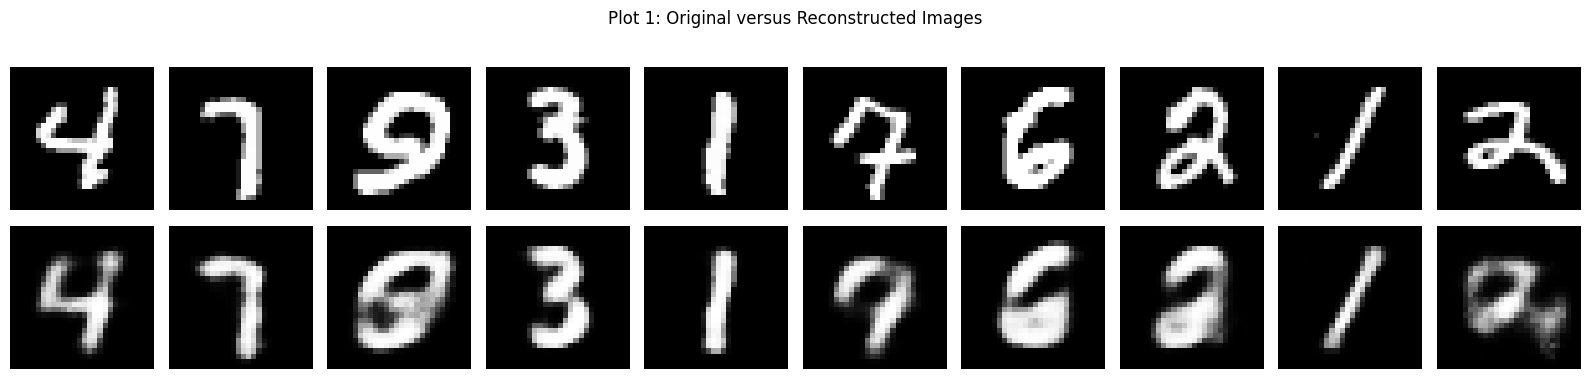

Inference:
- Digit shape should generally be preserved.
- Fine details may be lost because the image is flattened.
- Samples with unusual strokes can have larger reconstruction errors.


In [7]:
# Required Plot 1
plot_reconstructions(
    x_test[:10],
    fc_recon[:10],
    "Plot 1: Original versus Reconstructed Images",
    n=10
)

print("Inference:")
print("- Digit shape should generally be preserved.")
print("- Fine details may be lost because the image is flattened.")
print("- Samples with unusual strokes can have larger reconstruction errors.")

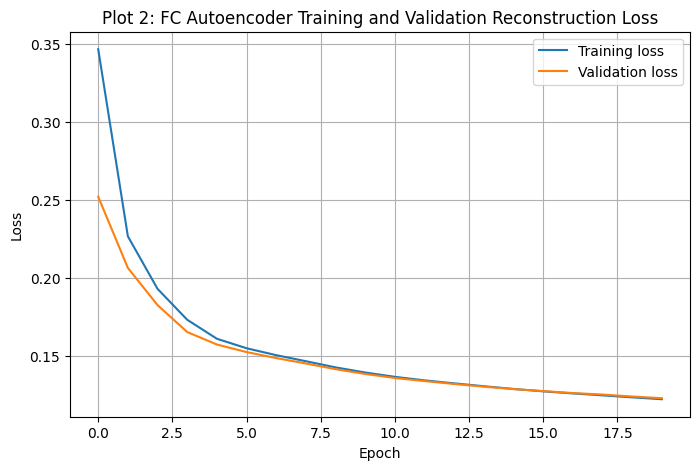

Final training loss:   0.122062
Final validation loss: 0.122733
Inference: compare the training and validation curves to check convergence and possible overfitting.


In [8]:
# Required Plot 2
plot_history(fc_history, "Plot 2: FC Autoencoder Training and Validation Reconstruction Loss")

final_train_loss = fc_history.history["loss"][-1]
final_val_loss = fc_history.history["val_loss"][-1]
print(f"Final training loss:   {final_train_loss:.6f}")
print(f"Final validation loss: {final_val_loss:.6f}")
print("Inference: compare the training and validation curves to check convergence and possible overfitting.")

In [9]:
# Required reconstruction metrics
fc_metrics_df = pd.DataFrame([fc_metrics])
display(fc_metrics_df.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Time (s)": "{:.2f}"
}))

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Fully Connected AE,0.019749,0.054336,0.775095,211040,32.07


Model: "CAE_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CAE_Encoder_16 (Functional)     │ (None, 16)             │       105,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CAE_Decoder_16 (Functional)     │ (None, 28, 28, 1)      │       108,993 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,929 (839.57 KB)

 Trainable params: 214,929 (839.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.3069 - val_loss: 0.2445
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1917 - val_loss: 0.1478
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1302 - val_loss: 0.1191
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1115 - val_loss: 0.1083
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1038 - val_loss: 0.1027
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0996 - val_loss: 0.0990
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0969 - val_loss: 0.0980
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0949 - val_loss: 0.0968
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0935 - val_loss: 0.0986
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0931 - val_loss: 0.0955
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0915 - val_loss: 0.0931
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0

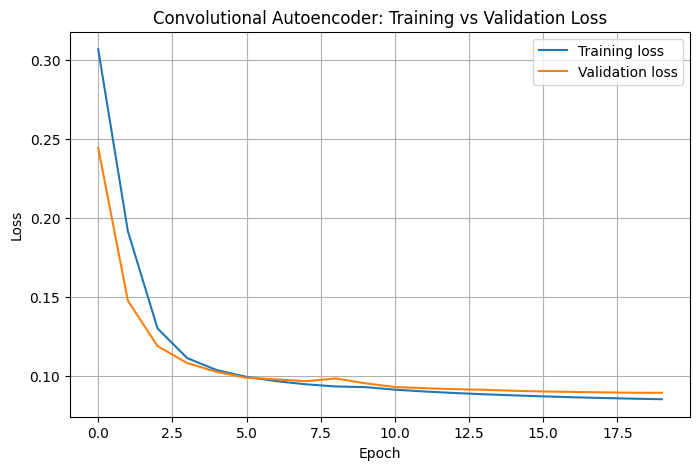

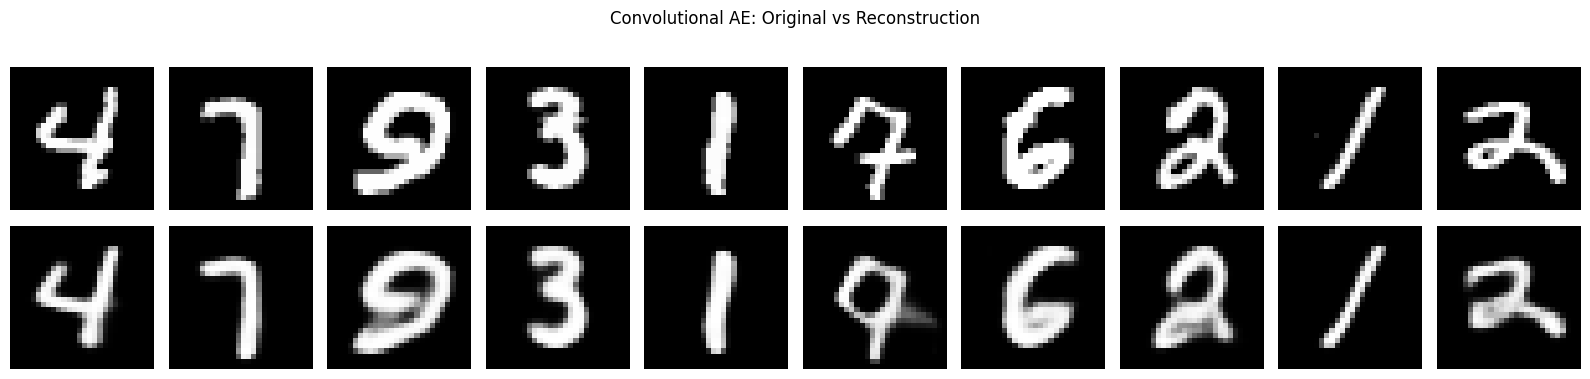

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Convolutional AE,0.009042,0.030576,0.907625,214929,42.771405


In [10]:
# =========================
# 10. Convolutional Autoencoder
# =========================
def build_cae(latent_dim=16):
    inp = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)       # 14x14
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)       # 7x7
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    feature_shape = x.shape[1:]
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name="latent")(x)

    encoder = Model(inp, z, name=f"CAE_Encoder_{latent_dim}")

    latent_in = keras.Input(shape=(latent_dim,), name="latent_input")
    x = layers.Dense(int(np.prod(feature_shape)), activation="relu")(latent_in)
    x = layers.Reshape(feature_shape)(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    decoder = Model(latent_in, out, name=f"CAE_Decoder_{latent_dim}")
    autoencoder = Model(inp, decoder(encoder(inp)), name=f"CAE_{latent_dim}")

    return autoencoder, encoder, decoder

cae, cae_encoder, cae_decoder = build_cae(BASE_LATENT_DIM)
cae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
cae.summary()

cae_history, cae_time = train_model(cae, x_train, xval=x_test, epochs=EPOCHS)
cae_recon = cae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

plot_history(cae_history, "Convolutional Autoencoder: Training vs Validation Loss")
plot_reconstructions(x_test, cae_recon, "Convolutional AE: Original vs Reconstruction", 10)

cae_metrics = metrics_row("Convolutional AE", cae, x_test, cae_recon, cae_time)
display(pd.DataFrame([cae_metrics]))

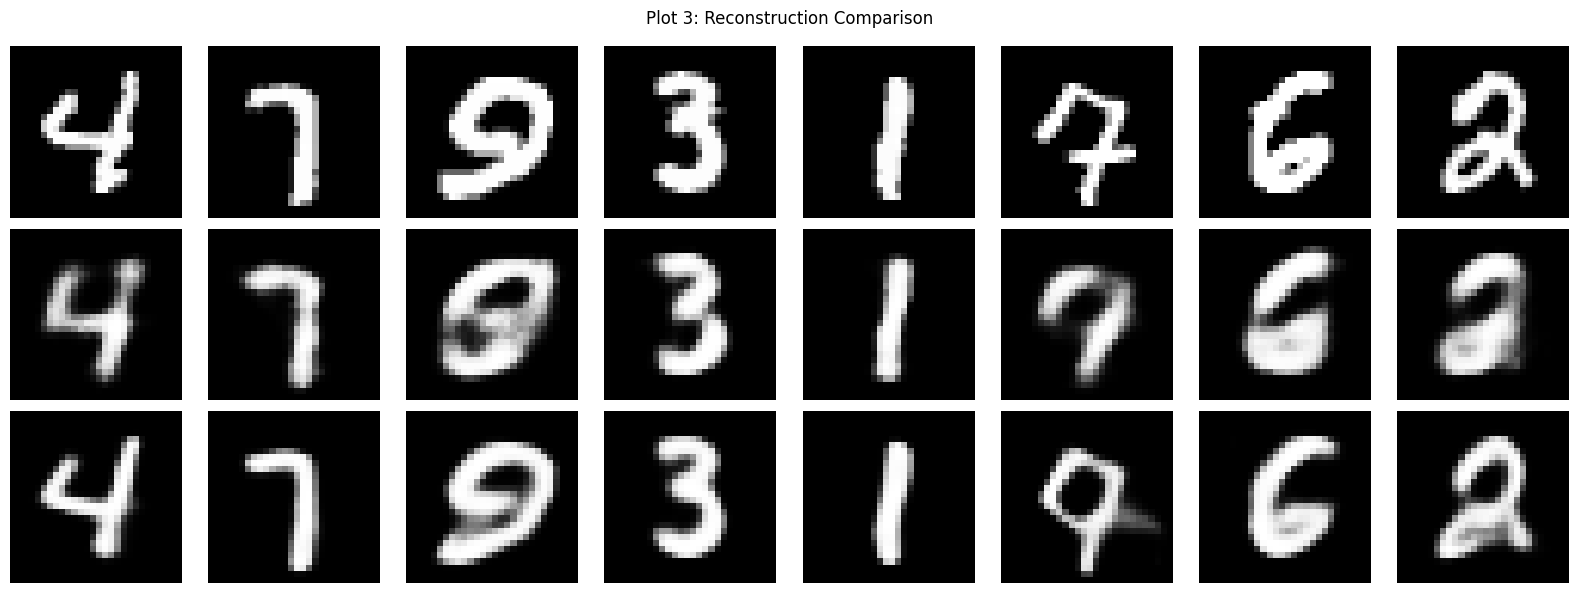

Inference:
- The convolutional model preserves local spatial structure directly.
- The fully connected model loses explicit 2-D locality after flattening.


In [11]:
# Required Plot 3
n = 8
plt.figure(figsize=(16, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("Original")

    plt.subplot(3, n, n + i + 1)
    plt.imshow(fc_recon[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("FC-AE")

    plt.subplot(3, n, 2*n + i + 1)
    plt.imshow(cae_recon[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("Conv-AE")

plt.suptitle("Plot 3: Reconstruction Comparison")
plt.tight_layout()
plt.show()

print("Inference:")
print("- The convolutional model preserves local spatial structure directly.")
print("- The fully connected model loses explicit 2-D locality after flattening.")

In [12]:
# Comparison table for Section 11
comparison_df = pd.DataFrame([fc_metrics, cae_metrics])[
    ["Model", "MSE", "MAE", "SSIM", "Parameters"]
]
display(comparison_df.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}"
}))

,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.019749,0.054336,0.775095,"211,040"
1,Convolutional AE,0.009042,0.030576,0.907625,"214,929"


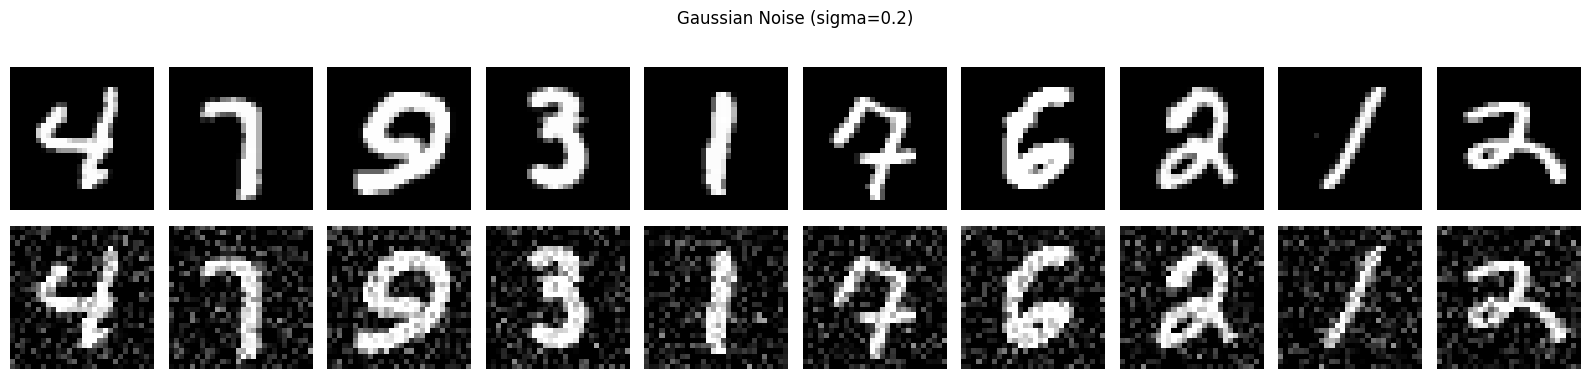

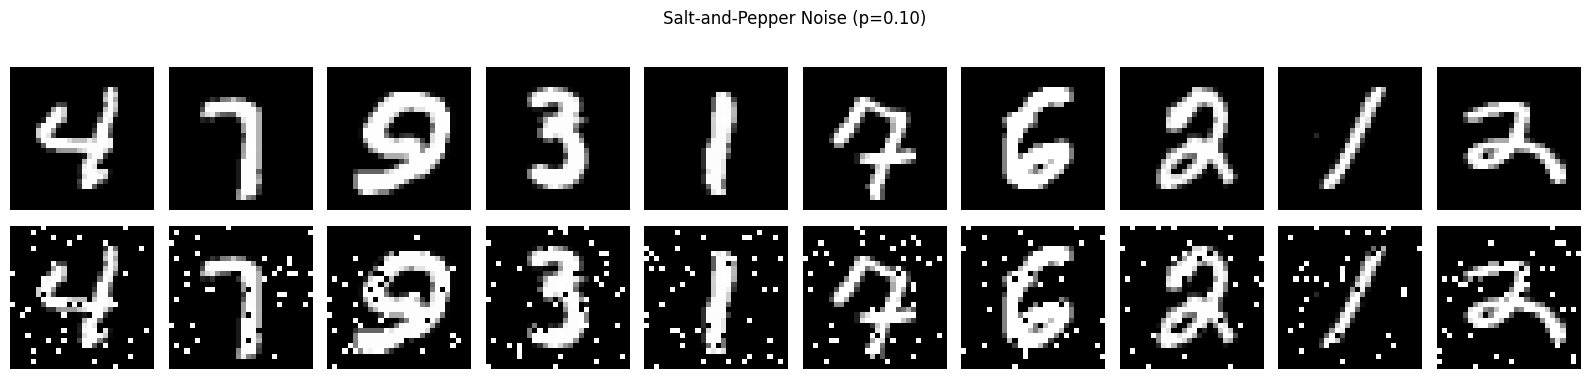

In [13]:
# =========================
# 12. Noise functions
# =========================
def add_gaussian_noise(images, sigma=0.2):
    noise = np.random.normal(0, sigma, images.shape).astype("float32")
    return np.clip(images + noise, 0, 1)

def add_salt_pepper_noise(images, probability=0.10):
    noisy = images.copy()
    rnd = np.random.random(images.shape)
    noisy[rnd < probability / 2] = 0.0
    noisy[(rnd >= probability / 2) & (rnd < probability)] = 1.0
    return noisy

def show_noise_examples(clean, noisy, title, n=10):
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(clean[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("Clean")
        plt.subplot(2, n, n+i+1)
        plt.imshow(noisy[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("Noisy")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

x_train_gaussian = add_gaussian_noise(x_train, 0.2)
x_test_gaussian = add_gaussian_noise(x_test, 0.2)

x_train_sp = add_salt_pepper_noise(x_train, 0.10)
x_test_sp = add_salt_pepper_noise(x_test, 0.10)

show_noise_examples(x_test[:10], x_test_gaussian[:10], "Gaussian Noise (sigma=0.2)")
show_noise_examples(x_test[:10], x_test_sp[:10], "Salt-and-Pepper Noise (p=0.10)")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.3046 - val_loss: 0.2601
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2279 - val_loss: 0.1812
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1514 - val_loss: 0.1302
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1212 - val_loss: 0.1145
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1106 - val_loss: 0.1085
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1055 - val_loss: 0.1100
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1023 - val_loss: 0.1040
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0999 - val_loss: 0.1007
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0981 - val_loss: 0.0995
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0962 - val_loss: 0.0979
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0947 - val_loss: 0.0972
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0

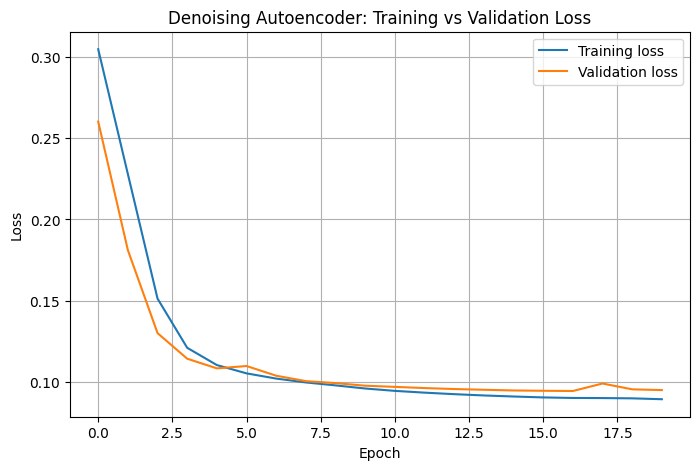

In [14]:
# =========================
# 13. Denoising CAE
# =========================
dae, dae_encoder, dae_decoder = build_cae(BASE_LATENT_DIM)
dae._name = "Denoising_CAE"
dae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")

dae_history, dae_time = train_model(
    dae,
    x_train_gaussian,
    ytr=x_train,
    xval=x_test_gaussian,
    yval=x_test,
    epochs=EPOCHS
)

dae_recon_gaussian = dae.predict(x_test_gaussian, batch_size=BATCH_SIZE, verbose=0)

plot_history(dae_history, "Denoising Autoencoder: Training vs Validation Loss")

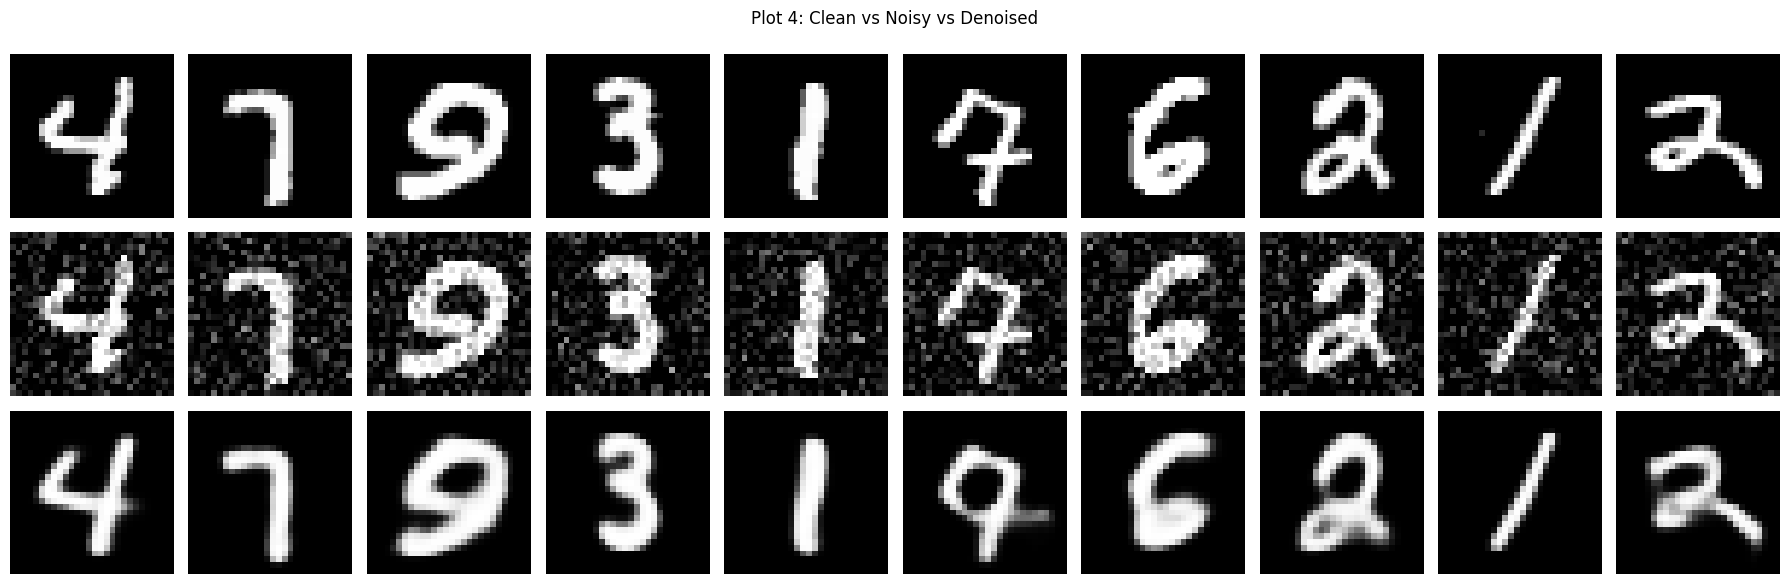

Inference:
- Increasing corruption makes the input less informative.
- A trained denoising autoencoder learns to recover the major digit structure.


In [15]:
# Required Plot 4
n = 10
plt.figure(figsize=(18, 6))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("Clean")

    plt.subplot(3, n, n+i+1)
    plt.imshow(x_test_gaussian[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("Noisy")

    plt.subplot(3, n, 2*n+i+1)
    plt.imshow(dae_recon_gaussian[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("Denoised")

plt.suptitle("Plot 4: Clean vs Noisy vs Denoised")
plt.tight_layout()
plt.show()

print("Inference:")
print("- Increasing corruption makes the input less informative.")
print("- A trained denoising autoencoder learns to recover the major digit structure.")

,Noise Level,MSE,MAE,SSIM
0,0.1,0.010428,0.032869,0.891667
1,0.2,0.010783,0.033913,0.887150
2,0.3,0.012672,0.038535,0.861059


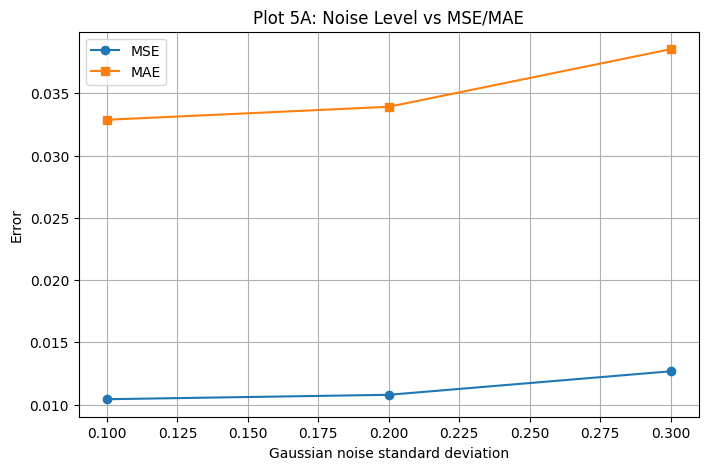

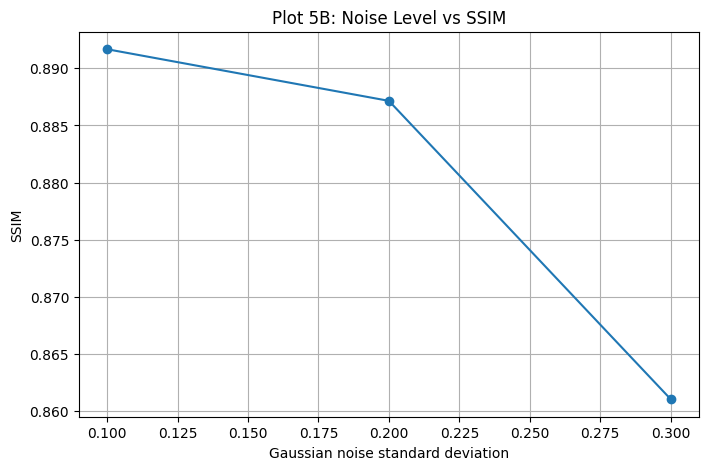

Inference: reconstruction quality generally decreases as Gaussian noise increases.


In [16]:
# Required Plot 5
noise_levels = [0.1, 0.2, 0.3]
noise_results = []

for sigma in noise_levels:
    noisy_test = add_gaussian_noise(x_test, sigma)
    recon = dae.predict(noisy_test, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim_value = calculate_metrics(x_test, recon)
    noise_results.append({
        "Noise Level": sigma,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

noise_df = pd.DataFrame(noise_results)
display(noise_df.style.format({
    "Noise Level": "{:.1f}",
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}"
}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(noise_df["Noise Level"], noise_df["MSE"], marker="o", label="MSE")
ax.plot(noise_df["Noise Level"], noise_df["MAE"], marker="s", label="MAE")
ax.set_xlabel("Gaussian noise standard deviation")
ax.set_ylabel("Error")
ax.set_title("Plot 5A: Noise Level vs MSE/MAE")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(noise_df["Noise Level"], noise_df["SSIM"], marker="o")
ax.set_xlabel("Gaussian noise standard deviation")
ax.set_ylabel("SSIM")
ax.set_title("Plot 5B: Noise Level vs SSIM")
ax.grid(True)
plt.show()

print("Inference: reconstruction quality generally decreases as Gaussian noise increases.")

In [17]:
# Denoising model metrics on Gaussian sigma=0.2
dae_metrics = metrics_row("Denoising CAE", dae, x_test, dae_recon_gaussian, dae_time)
display(pd.DataFrame([dae_metrics]).style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Time (s)": "{:.2f}",
    "Parameters": "{:,}"
}))

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Denoising CAE,0.010794,0.033934,0.887208,"214,929",27.49


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# =========================
# 16. VAE with reparameterization
# =========================
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data, training=False)
        reconstruction = self.decoder(z, training=False)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

def build_vae(latent_dim=2):
    # Encoder
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inp)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

    def sampling(args):
        z_mean, z_log_var = args
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

    encoder = Model(inp, [z_mean, z_log_var, z], name=f"VAE_Encoder_{latent_dim}")

    # Decoder
    latent_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation="relu")(latent_in)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    decoder = Model(latent_in, out, name=f"VAE_Decoder_{latent_dim}")

    vae = VAE(encoder, decoder, name=f"VAE_{latent_dim}")
    return vae, encoder, decoder

vae, vae_encoder, vae_decoder = build_vae(VAE_LATENT_DIM)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
vae.build(x_train.shape[1:]) # Add this line to explicitly build the VAE model

start = time.time()
vae_history = vae.fit(
    x_train,
    validation_data=(x_test,),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
vae_time = time.time() - start

z_mean_test, z_log_var_test, z_test = vae_encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
vae_recon = vae_decoder.predict(z_test, batch_size=BATCH_SIZE, verbose=0)

print("VAE parameters:", count_parameters(vae))
print("Training time:", round(vae_time, 2), "seconds")

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - kl_loss: 4.7130 - loss: 282.5109 - reconstruction_loss: 277.7979 - val_kl_loss: 3.7364 - val_loss: 206.8959 - val_reconstruction_loss: 203.1595
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.1648 - loss: 199.0463 - reconstruction_loss: 195.8815 - val_kl_loss: 3.0477 - val_loss: 197.5175 - val_reconstruction_loss: 194.4698
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.7162 - loss: 187.8878 - reconstruction_loss: 184.1716 - val_kl_loss: 3.9854 - val_loss: 184.7773 - val_reconstruction_loss: 180.7918
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.2017 - loss: 180.8233 - reconstruction_loss: 176.6215 - val_kl_loss: 4.3024 - val_loss: 180.9870 - val_reconstruction_loss: 176.6846
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.3338 - loss: 178.3080 - reconstruction_loss: 173.9742 - val_kl_loss: 4.2754 - val_loss: 179.5977 - val_reconstruction_loss: 175.3223
Epoch 6/20
79/79 ━

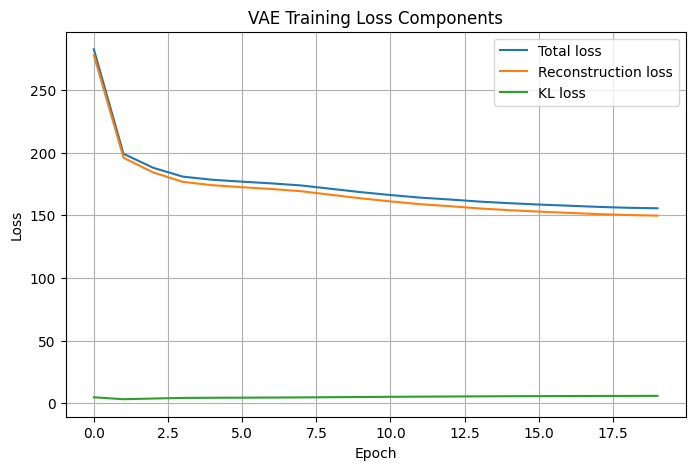

,Model,MSE,MAE,SSIM,Parameters,Time (s),Reconstruction Loss,KL Loss,Total Loss
0,VAE,0.044951,0.105706,0.509435,"485,957",23.45,149.709137,5.852229,155.561356


In [20]:
# =========================
# 17. VAE losses and metrics
# =========================
plt.figure(figsize=(8, 5))
plt.plot(vae_history.history["loss"], label="Total loss")
plt.plot(vae_history.history["reconstruction_loss"], label="Reconstruction loss")
plt.plot(vae_history.history["kl_loss"], label="KL loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Components")
plt.legend()
plt.grid(True)
plt.show()

vae_mse, vae_mae, vae_ssim = calculate_metrics(x_test, vae_recon)

vae_final_recon_loss = float(vae_history.history["reconstruction_loss"][-1])
vae_final_kl_loss = float(vae_history.history["kl_loss"][-1])
vae_final_total_loss = float(vae_history.history["loss"][-1])

vae_metrics = {
    "Model": "VAE",
    "MSE": vae_mse,
    "MAE": vae_mae,
    "SSIM": vae_ssim,
    "Parameters": count_parameters(vae),
    "Time (s)": vae_time,
    "Reconstruction Loss": vae_final_recon_loss,
    "KL Loss": vae_final_kl_loss,
    "Total Loss": vae_final_total_loss
}

display(pd.DataFrame([vae_metrics]).style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Time (s)": "{:.2f}",
    "Reconstruction Loss": "{:.6f}",
    "KL Loss": "{:.6f}",
    "Total Loss": "{:.6f}",
    "Parameters": "{:,}"
}))

## 18. Plot 6: VAE latent-space visualization

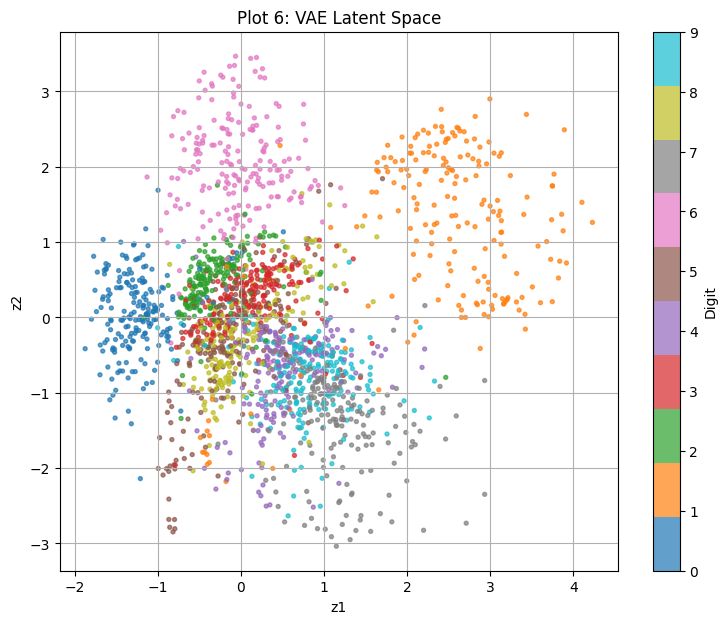

Inference:
- Images of the same digit should tend to occupy nearby regions.
- Some digits may overlap because the latent space is only two-dimensional.


In [21]:
# Required Plot 6
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7
)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Plot 6: VAE Latent Space")
plt.colorbar(scatter, label="Digit")
plt.grid(True)
plt.show()

print("Inference:")
print("- Images of the same digit should tend to occupy nearby regions.")
print("- Some digits may overlap because the latent space is only two-dimensional.")

## 19. Plot 7: Randomly generated VAE images

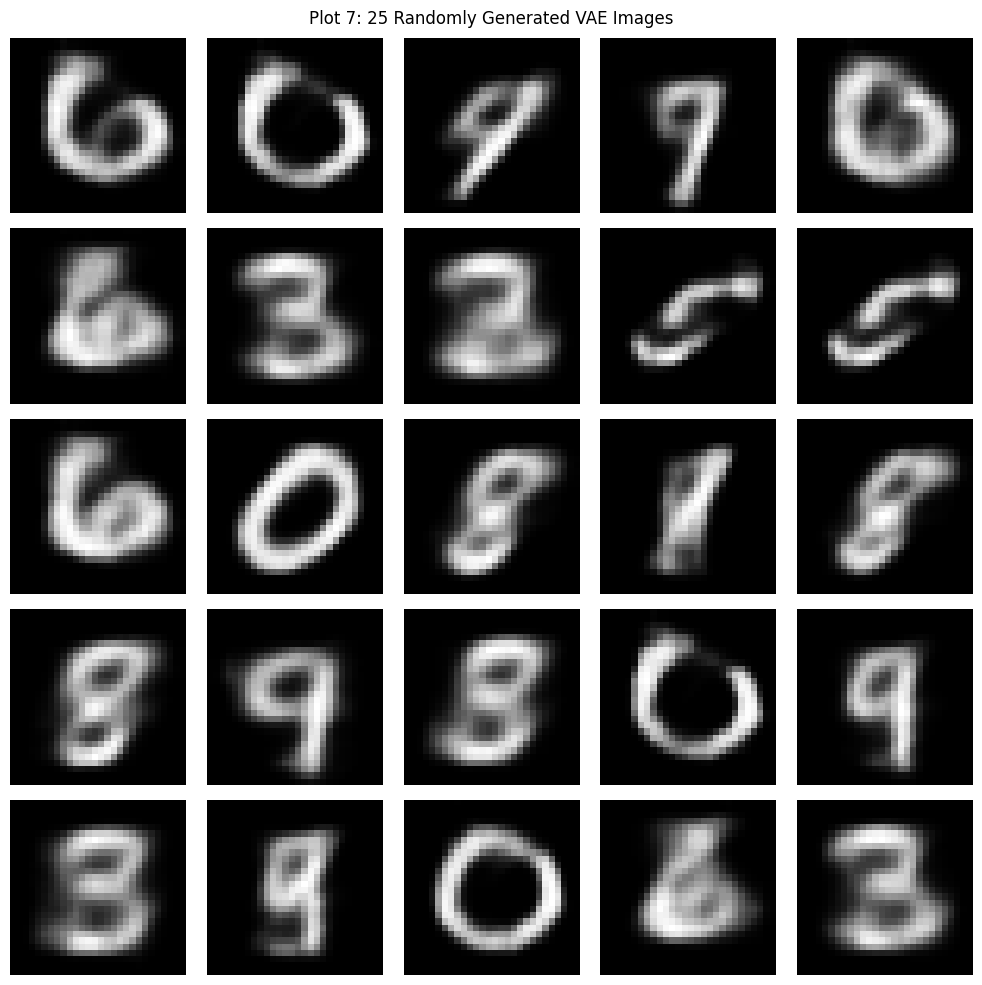

Inference:
- Generated samples should resemble MNIST digits.
- VAE samples are usually smooth but can be blurry.
- Variation is expected because each latent vector is sampled from N(0, I).


In [22]:
# Required Plot 7
def generate_vae_images(decoder, n=25, latent_dim=2):
    z = np.random.normal(size=(n, latent_dim)).astype("float32")
    return decoder.predict(z, verbose=0)

generated_25 = generate_vae_images(vae_decoder, 25, VAE_LATENT_DIM)

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(generated_25[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Plot 7: 25 Randomly Generated VAE Images")
plt.tight_layout()
plt.show()

print("Inference:")
print("- Generated samples should resemble MNIST digits.")
print("- VAE samples are usually smooth but can be blurry.")
print("- Variation is expected because each latent vector is sampled from N(0, I).")

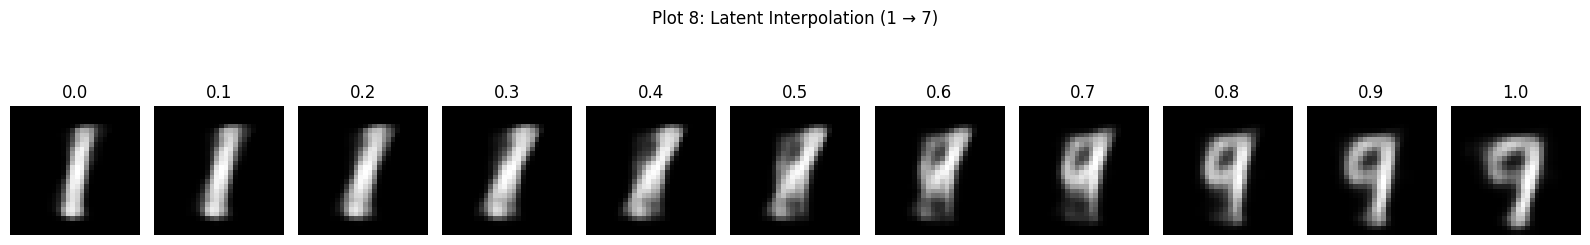

Inference:
- A smooth sequence indicates that nearby latent points decode to gradually changing images.


In [23]:
# Required Plot 8
def find_two_digit_indices(labels, digit_a, digit_b):
    ia = np.where(labels == digit_a)[0][0]
    ib = np.where(labels == digit_b)[0][0]
    return ia, ib

digit_a, digit_b = 1, 7
ia, ib = find_two_digit_indices(y_test, digit_a, digit_b)

z_a = z_mean_test[ia]
z_b = z_mean_test[ib]

alphas = np.linspace(0, 1, 11)
interpolated_z = np.array([(1-a)*z_a + a*z_b for a in alphas], dtype="float32")
interpolated_images = vae_decoder.predict(interpolated_z, verbose=0)

plt.figure(figsize=(16, 3))
for i, alpha in enumerate(alphas):
    plt.subplot(1, 11, i+1)
    plt.imshow(interpolated_images[i].squeeze(), cmap="gray")
    plt.title(f"{alpha:.1f}")
    plt.axis("off")
plt.suptitle(f"Plot 8: Latent Interpolation ({digit_a} → {digit_b})")
plt.tight_layout()
plt.show()

print("Inference:")
print("- A smooth sequence indicates that nearby latent points decode to gradually changing images.")

In [24]:
# =========================
# 21. Main comparison table
# =========================
all_main_metrics = pd.DataFrame([
    fc_metrics,
    cae_metrics,
    dae_metrics,
    {
        "Model": "VAE",
        "MSE": vae_mse,
        "MAE": vae_mae,
        "SSIM": vae_ssim,
        "Parameters": count_parameters(vae),
        "Time (s)": vae_time
    }
])

display(all_main_metrics.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Fully Connected AE,0.019749,0.054336,0.775095,"211,040",32.07
1,Convolutional AE,0.009042,0.030576,0.907625,"214,929",42.77
2,Denoising CAE,0.010794,0.033934,0.887208,"214,929",27.49
3,VAE,0.044951,0.105706,0.509435,"485,957",23.45


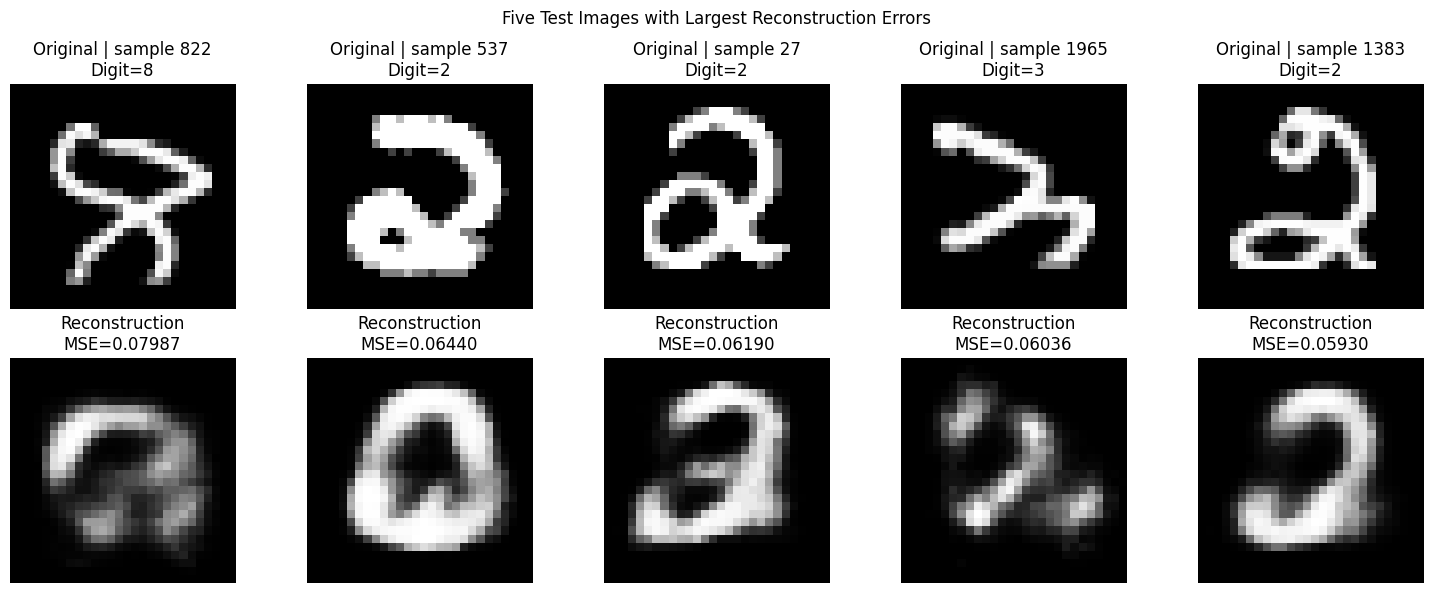

,Sample,Digit,Reconstruction MSE
0,823,8,0.079873
1,538,2,0.064400
2,28,2,0.061901
3,1966,3,0.060355
4,1384,2,0.059297


Typical reasons for high error:
- unusual writing style
- thick/thin strokes
- tilted or shifted digits
- ambiguous digit shape
- reconstruction blur


In [26]:
# =========================
# 23. Required high-error image analysis
# =========================
top5_idx = np.argsort(per_image_errors)[-5:][::-1]

plt.figure(figsize=(15, 6))
for j, idx in enumerate(top5_idx):
    plt.subplot(2, 5, j+1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(f"Original | sample {idx}\nDigit={y_test[idx]}")
    plt.axis("off")

    plt.subplot(2, 5, 5+j+1)
    plt.imshow(fc_recon[idx].squeeze(), cmap="gray")
    plt.title(f"Reconstruction\nMSE={per_image_errors[idx]:.5f}")
    plt.axis("off")

plt.suptitle("Five Test Images with Largest Reconstruction Errors")
plt.tight_layout()
plt.show()

high_error_table = pd.DataFrame({
    "Sample": top5_idx + 1,
    "Digit": y_test[top5_idx],
    "Reconstruction MSE": per_image_errors[top5_idx]
})
display(high_error_table.style.format({"Reconstruction MSE": "{:.6f}"}))

print("Typical reasons for high error:")
print("- unusual writing style")
print("- thick/thin strokes")
print("- tilted or shifted digits")
print("- ambiguous digit shape")
print("- reconstruction blur")

In [27]:
# =========================
# 24. Consolidated results table
# =========================
consolidated = pd.DataFrame([
    fc_metrics,
    cae_metrics,
    dae_metrics,
    {
        "Model": "VAE",
        "MSE": vae_mse,
        "MAE": vae_mae,
        "SSIM": vae_ssim,
        "Parameters": count_parameters(vae),
        "Time (s)": vae_time
    }
])

display(consolidated.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Fully Connected AE,0.019749,0.054336,0.775095,"211,040",32.07
1,Convolutional AE,0.009042,0.030576,0.907625,"214,929",42.77
2,Denoising CAE,0.010794,0.033934,0.887208,"214,929",27.49
3,VAE,0.044951,0.105706,0.509435,"485,957",23.45


In [28]:
# =========================
# 25. Train CAEs with latent dimensions 2, 8, 16, 32
# =========================
latent_dimensions = [2, 8, 16, 32]
latent_study_results = []
latent_models = {}

for dim in latent_dimensions:
    print("\n" + "="*60)
    print(f"Training CAE with latent dimension = {dim}")
    print("="*60)

    model, enc, dec = build_cae(dim)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy")

    start = time.time()
    h = model.fit(
        x_train, x_train,
        validation_data=(x_test, x_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    elapsed = time.time() - start

    recon = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim_value = calculate_metrics(x_test, recon)

    latent_study_results.append({
        "Latent Dimension": dim,
        "MSE": mse,
        "SSIM": ssim_value,
        "MAE": mae,
        "Parameters": count_parameters(model),
        "Time (s)": elapsed
    })

    latent_models[dim] = {
        "model": model,
        "encoder": enc,
        "decoder": dec,
        "history": h,
        "reconstruction": recon
    }

latent_df = pd.DataFrame(latent_study_results)
display(latent_df.style.format({
    "MSE": "{:.6f}",
    "SSIM": "{:.6f}",
    "MAE": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))


Training CAE with latent dimension = 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.3204 - val_loss: 0.2460
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2335 - val_loss: 0.2288
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2201 - val_loss: 0.2190
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2126 - val_loss: 0.2120
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2080 - val_loss: 0.2087
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2044 - val_loss: 0.2056
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2012 - val_loss: 0.2023
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1988 - val_loss: 0.2001
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1969 - val_loss: 0.1997
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1955 - val_loss: 0.1981
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1943 - val_loss: 0.1975
Epoch 12/20
79/79 ━━━━━

,Latent Dimension,MSE,SSIM,MAE,Parameters,Time (s)
0,2,0.043905,0.519688,0.103214,"127,107",28.58
1,8,0.017701,0.809183,0.048915,"164,745",29.68
2,16,0.009185,0.906874,0.030519,"214,929",27.48
3,32,0.005387,0.945413,0.022123,"315,297",28.09


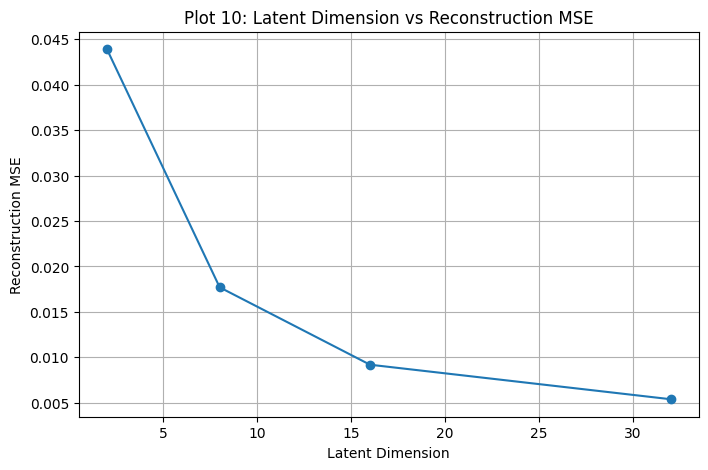

Inference:
- Very small latent spaces force stronger compression.
- Increasing latent dimension generally gives the decoder more information.
- After a point, the improvement may become small compared with the extra capacity.


In [29]:
# Required Plot 10
plt.figure(figsize=(8, 5))
plt.plot(
    latent_df["Latent Dimension"],
    latent_df["MSE"],
    marker="o"
)
plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction MSE")
plt.title("Plot 10: Latent Dimension vs Reconstruction MSE")
plt.grid(True)
plt.show()

print("Inference:")
print("- Very small latent spaces force stronger compression.")
print("- Increasing latent dimension generally gives the decoder more information.")
print("- After a point, the improvement may become small compared with the extra capacity.")

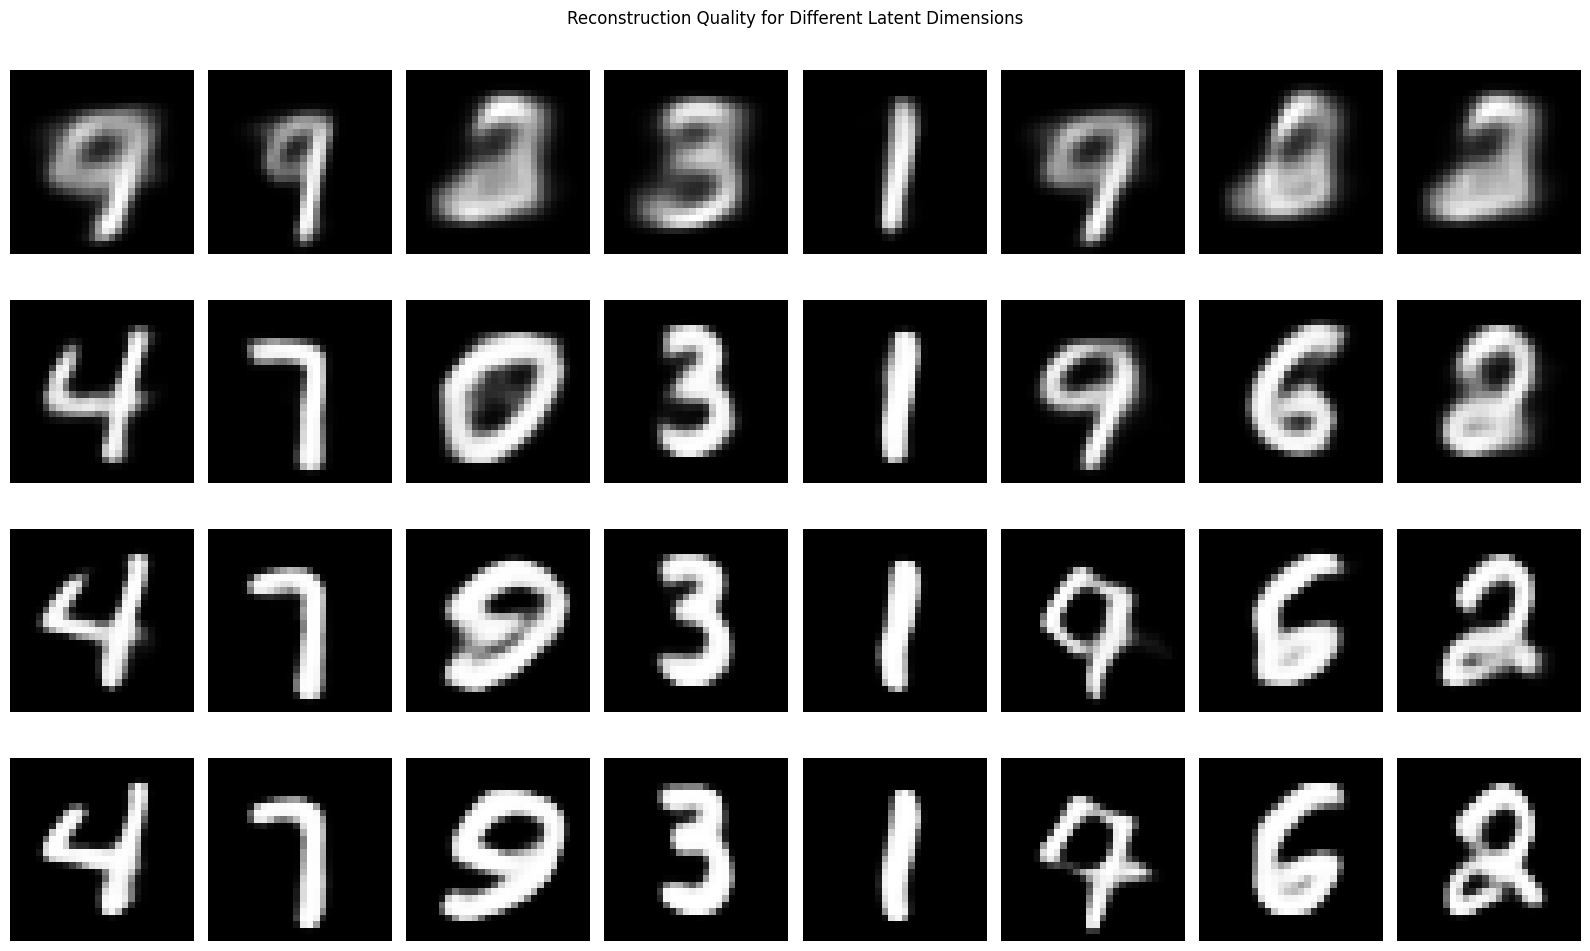

In [30]:
# Visual comparison for latent dimensions
sample_ids = range(8)

plt.figure(figsize=(16, 10))
for row, dim in enumerate(latent_dimensions):
    recon = latent_models[dim]["reconstruction"]
    for col, idx in enumerate(sample_ids):
        plt.subplot(len(latent_dimensions), 8, row*8 + col + 1)
        plt.imshow(recon[idx].squeeze(), cmap="gray")
        plt.axis("off")
        if col == 0:
            plt.ylabel(f"z={dim}")
plt.suptitle("Reconstruction Quality for Different Latent Dimensions")
plt.tight_layout()
plt.show()

,Noise Type,MSE,MAE,SSIM
0,Gaussian sigma=0.2,0.010794,0.033934,0.887208
1,Salt-and-Pepper p=0.10,0.013935,0.039648,0.847280


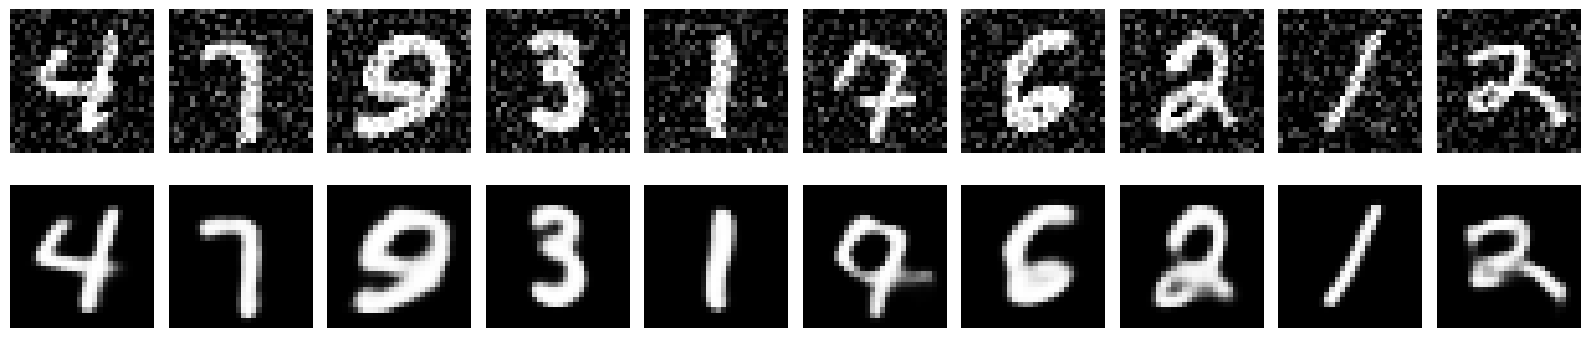

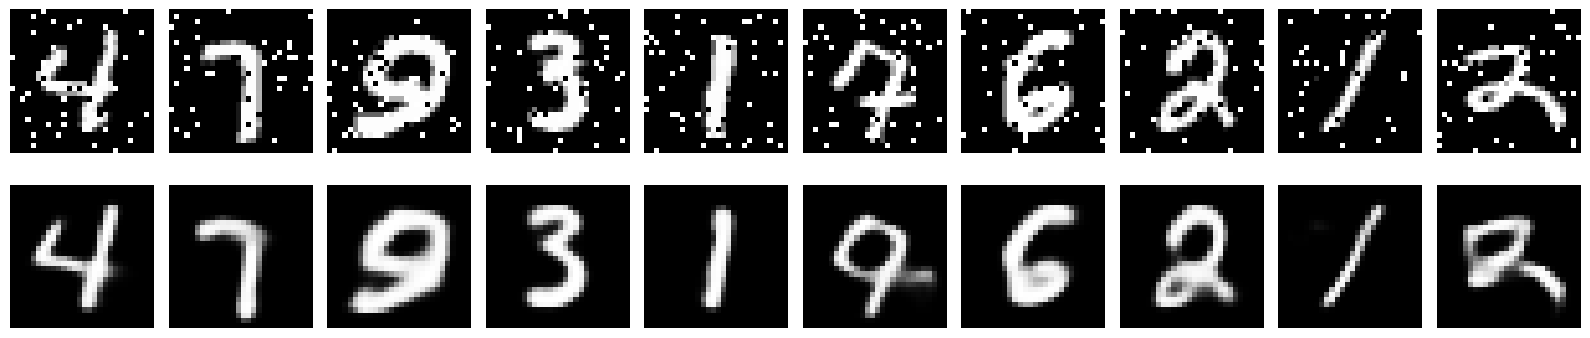

In [31]:
# =========================
# Additional Exercise 2
# =========================
noise_comparison = []

for noise_name, noisy in [
    ("Gaussian sigma=0.2", x_test_gaussian),
    ("Salt-and-Pepper p=0.10", x_test_sp)
]:
    recon = dae.predict(noisy, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim_value = calculate_metrics(x_test, recon)
    noise_comparison.append({
        "Noise Type": noise_name,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

noise_comparison_df = pd.DataFrame(noise_comparison)
display(noise_comparison_df.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}"
}))

for noise_name, noisy in [
    ("Gaussian", x_test_gaussian),
    ("Salt-and-Pepper", x_test_sp)
]:
    recon = dae.predict(noisy[:10], batch_size=BATCH_SIZE, verbose=0)
    plt.figure(figsize=(16, 4))
    for i in range(10):
        plt.subplot(2, 10, i+1)
        plt.imshow(noisy[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel(noise_name)
        plt.subplot(2, 10, 10+i+1)
        plt.imshow(recon[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("Denoised")
    plt.tight_layout()
    plt.show()

In [32]:
# =========================
# Additional Exercise 3
# =========================
additional_noise_levels = [0.1, 0.3]
additional_noise_rows = []

for sigma in additional_noise_levels:
    noisy = add_gaussian_noise(x_test, sigma)
    recon = dae.predict(noisy, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim_value = calculate_metrics(x_test, recon)
    additional_noise_rows.append({
        "Gaussian sigma": sigma,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

additional_noise_df = pd.DataFrame(additional_noise_rows)
display(additional_noise_df.style.format({
    "Gaussian sigma": "{:.1f}",
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}"
}))

,Gaussian sigma,MSE,MAE,SSIM
0,0.1,0.010439,0.032883,0.891586
1,0.3,0.012691,0.038632,0.860774


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.3393 - val_loss: 0.2599
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2370 - val_loss: 0.2055
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1710 - val_loss: 0.1465
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1334 - val_loss: 0.1212
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1158 - val_loss: 0.1116
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1080 - val_loss: 0.1062
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1032 - val_loss: 0.1035
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1003 - val_loss: 0.1014
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0982 - val_loss: 0.1006
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0969 - val_loss: 0.0978
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0952 - val_loss: 0.0967
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0

,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Convolutional AE,0.009042,0.030576,0.907625,"214,929",42.77
1,CAE with Transposed Conv Decoder,0.010089,0.032703,0.897647,"214,929",28.09


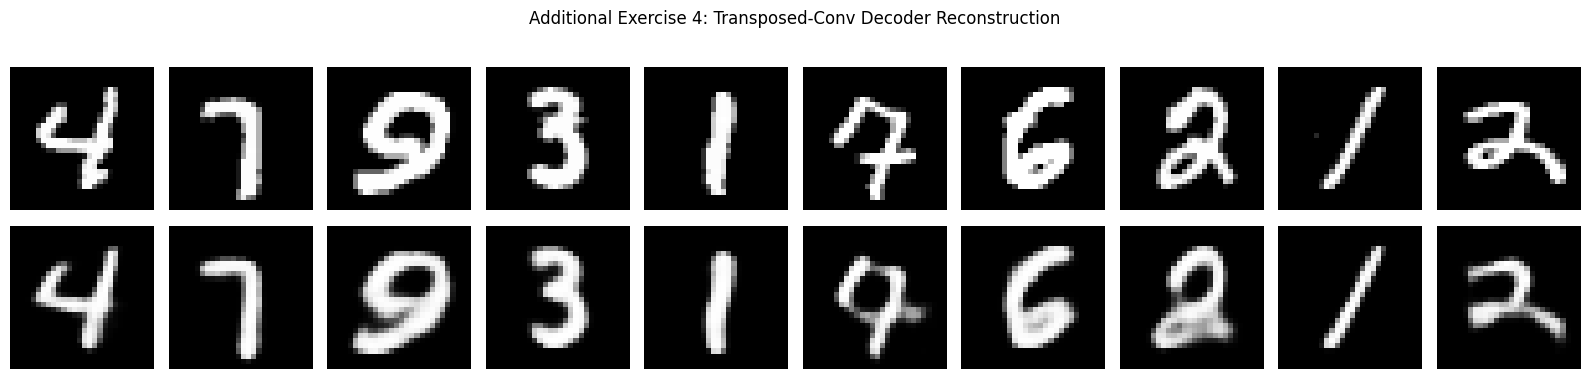

In [33]:
# =========================
# Additional Exercise 4
# Alternate CAE decoder with Conv2DTranspose
# =========================
def build_cae_transpose(latent_dim=16):
    inp = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    feature_shape = x.shape[1:]
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, name="latent")(x)

    encoder = Model(inp, z)

    latent_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(int(np.prod(feature_shape)), activation="relu")(latent_in)
    x = layers.Reshape(feature_shape)(x)

    # Two transposed-convolution upsampling stages
    x = layers.Conv2DTranspose(
        64, 3, activation="relu", strides=2, padding="same"
    )(x)
    x = layers.Conv2DTranspose(
        32, 3, activation="relu", strides=2, padding="same"
    )(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    decoder = Model(latent_in, out)
    model = Model(inp, decoder(encoder(inp)), name="CAE_Transpose")
    return model, encoder, decoder

cae_trans, trans_enc, trans_dec = build_cae_transpose(16)
cae_trans.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy")

trans_history, trans_time = train_model(
    cae_trans, x_train, xval=x_test, epochs=EPOCHS
)
trans_recon = cae_trans.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

trans_metrics = metrics_row(
    "CAE with Transposed Conv Decoder",
    cae_trans,
    x_test,
    trans_recon,
    trans_time
)

display(pd.DataFrame([cae_metrics, trans_metrics]).style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

plot_reconstructions(
    x_test[:10],
    trans_recon[:10],
    "Additional Exercise 4: Transposed-Conv Decoder Reconstruction",
    10
)


Training VAE latent dimension: 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - kl_loss: 2.1675 - loss: 297.5694 - reconstruction_loss: 295.4019 - val_kl_loss: 0.2575 - val_loss: 215.0412 - val_reconstruction_loss: 214.7836
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 0.6682 - loss: 208.7550 - reconstruction_loss: 208.0869 - val_kl_loss: 2.3438 - val_loss: 201.7107 - val_reconstruction_loss: 199.3669
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.7220 - loss: 195.6080 - reconstruction_loss: 192.8860 - val_kl_loss: 3.4978 - val_loss: 191.2353 - val_reconstruction_loss: 187.7375
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.6145 - loss: 185.2628 - reconstruction_loss: 181.6482 - val_kl_loss: 3.6717 - val_loss: 184.5704 - val_reconstruction_loss: 180.8987
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.0287 - loss: 180.4742 - reconstruction_loss: 176.4454 - val_kl_loss: 4.1896 - val_loss: 180.7195 - val_reconstruction

,VAE Latent Dimension,MSE,MAE,SSIM,Parameters,Time (s)
0,2,0.044929,0.105644,0.508429,"485,957",23.88
1,8,0.021683,0.057596,0.772349,"506,321",24.09


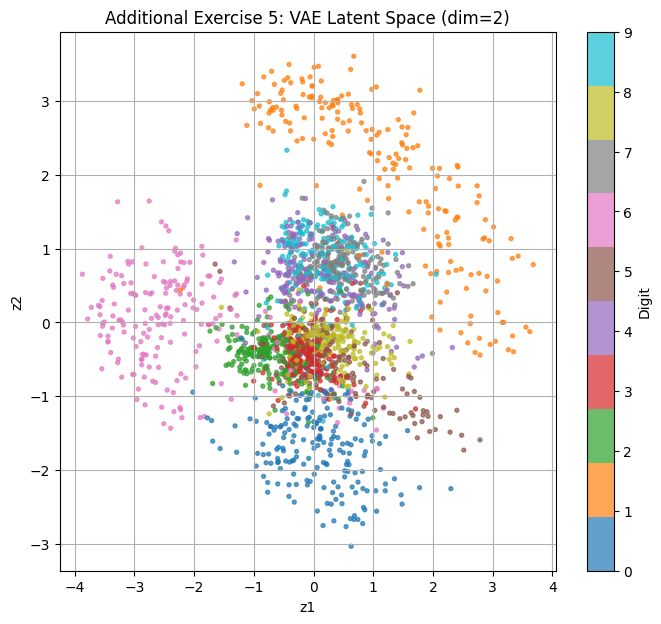

In [35]:
# =========================
# Additional Exercise 5
# =========================
vae_dimension_results = []
vae_models = {}

for dim in [2, 8]:
    print("\nTraining VAE latent dimension:", dim)
    model, enc, dec = build_vae(dim)
    model.compile(optimizer=keras.optimizers.Adam(1e-3))
    model.build(x_train.shape[1:]) # Add this line to explicitly build the VAE model

    start = time.time()
    h = model.fit(
        x_train,
        validation_data=(x_test,),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    elapsed = time.time() - start

    zmean, zlog, zsample = enc.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    recon = dec.predict(zsample, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, ssim_value = calculate_metrics(x_test, recon)

    vae_dimension_results.append({
        "VAE Latent Dimension": dim,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value,
        "Parameters": count_parameters(model),
        "Time (s)": elapsed
    })

    vae_models[dim] = {
        "model": model,
        "encoder": enc,
        "decoder": dec,
        "history": h,
        "z_mean": zmean,
        "reconstruction": recon
    }

vae_dim_df = pd.DataFrame(vae_dimension_results)
display(vae_dim_df.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

# Plot the 2-D VAE latent representation
z2 = vae_models[2]["z_mean"]
plt.figure(figsize=(8, 7))
sc = plt.scatter(z2[:,0], z2[:,1], c=y_test, cmap="tab10", s=8, alpha=0.7)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Additional Exercise 5: VAE Latent Space (dim=2)")
plt.colorbar(sc, label="Digit")
plt.grid(True)
plt.show()

In [36]:
# =========================
# Additional Exercise 6
# Compare different beta values in beta-VAE
# =========================
class BetaVAE(VAE):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(encoder, decoder, **kwargs)
        self.beta = beta

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

beta_results = []

for beta in [0.1, 1.0, 2.0]:
    base_vae, enc, dec = build_vae(2)
    beta_vae = BetaVAE(enc, dec, beta=beta, name=f"BetaVAE_{beta}")
    beta_vae.compile(optimizer=keras.optimizers.Adam(1e-3))

    beta_vae.fit(
        x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    zmean, zlog, zsample = enc.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    recon = dec.predict(zsample, batch_size=BATCH_SIZE, verbose=0)

    mse, mae, ssim_value = calculate_metrics(x_test, recon)
    beta_results.append({
        "Beta": beta,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

beta_df = pd.DataFrame(beta_results)
display(beta_df.style.format({
    "Beta": "{:.1f}",
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}"
}))

,Beta,MSE,MAE,SSIM
0,0.1,0.044087,0.105404,0.510574
1,1.0,0.045172,0.105574,0.503694
2,2.0,0.046666,0.109257,0.484693


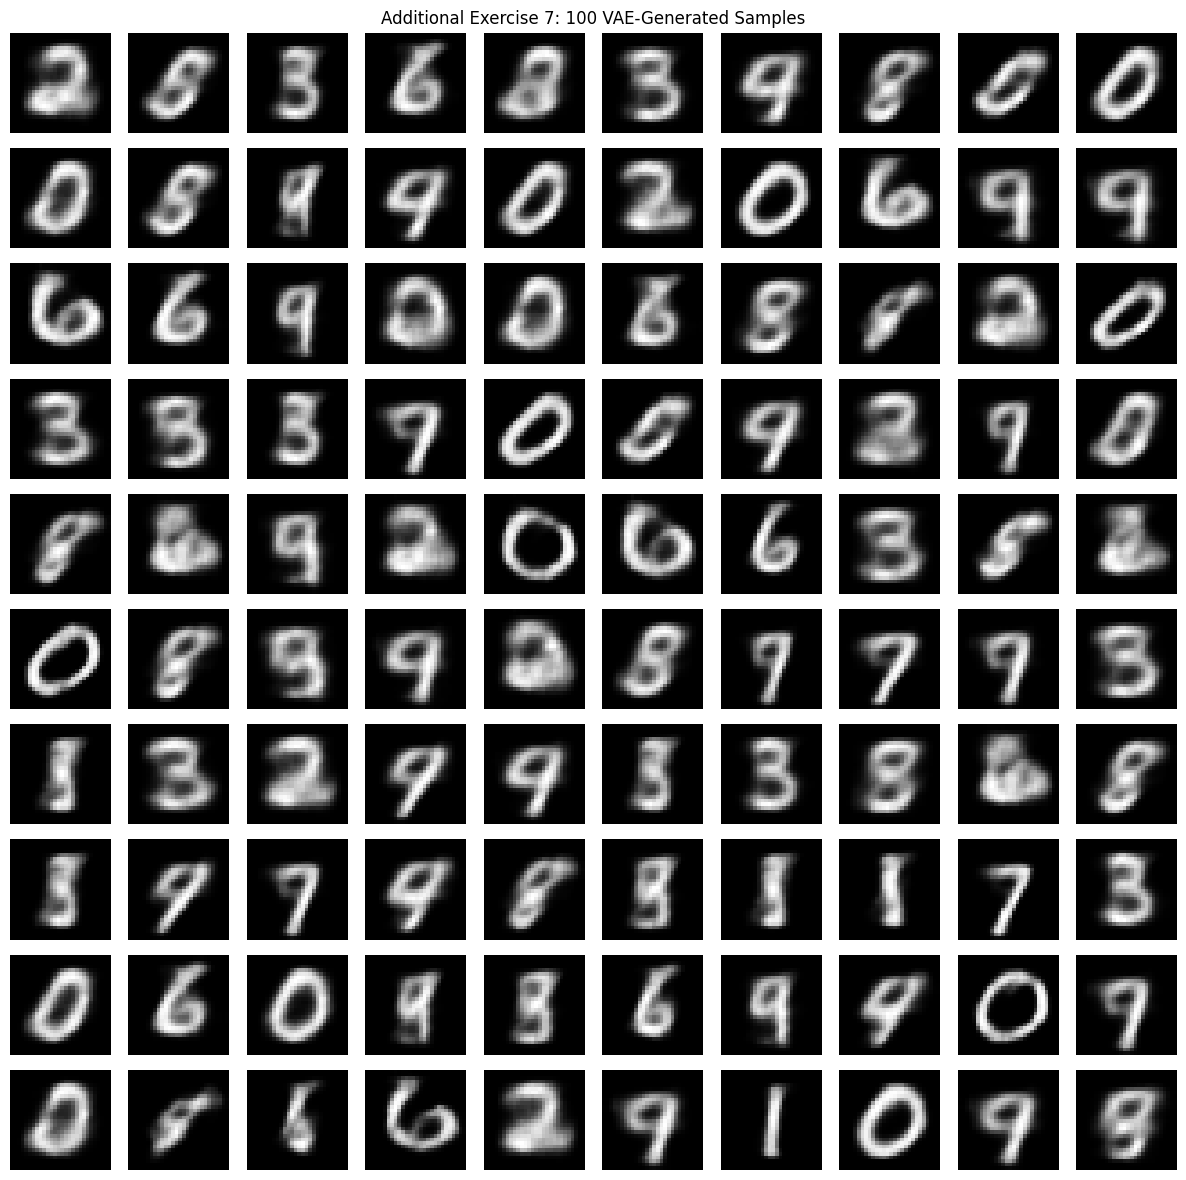

In [37]:
# =========================
# Additional Exercise 7
# =========================
generated_100 = generate_vae_images(vae_decoder, 100, VAE_LATENT_DIM)

plt.figure(figsize=(12, 12))
for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.imshow(generated_100[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Additional Exercise 7: 100 VAE-Generated Samples")
plt.tight_layout()
plt.show()

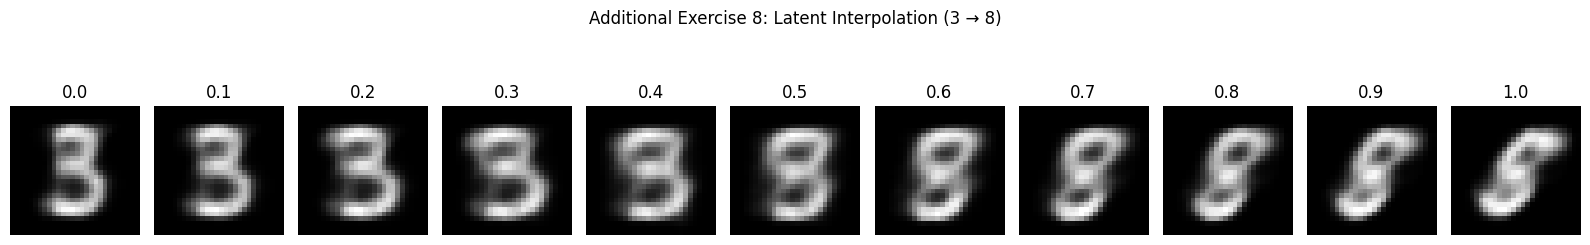

In [38]:
# =========================
# Additional Exercise 8
# Automatically select two well-separated digit representatives
# =========================
# Use digits 3 and 8 for a second interpolation experiment.
digit_a2, digit_b2 = 3, 8
ia2, ib2 = find_two_digit_indices(y_test, digit_a2, digit_b2)

za2 = z_mean_test[ia2]
zb2 = z_mean_test[ib2]

alphas2 = np.linspace(0, 1, 11)
z_interp2 = np.array([(1-a)*za2 + a*zb2 for a in alphas2], dtype="float32")
imgs_interp2 = vae_decoder.predict(z_interp2, verbose=0)

plt.figure(figsize=(16, 3))
for i, alpha in enumerate(alphas2):
    plt.subplot(1, 11, i+1)
    plt.imshow(imgs_interp2[i].squeeze(), cmap="gray")
    plt.title(f"{alpha:.1f}")
    plt.axis("off")
plt.suptitle(f"Additional Exercise 8: Latent Interpolation ({digit_a2} → {digit_b2})")
plt.tight_layout()
plt.show()

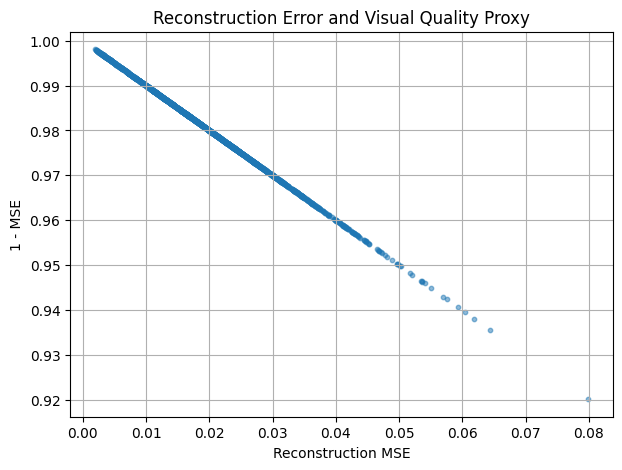

In [41]:
# =========================
# Final analysis helpers
# =========================
plt.figure(figsize=(7, 5))
plt.scatter(per_image_errors, 1 - per_image_errors, s=10, alpha=0.5)
plt.xlabel("Reconstruction MSE")
plt.ylabel("1 - MSE")
plt.title("Reconstruction Error and Visual Quality Proxy")
plt.grid(True)
plt.show()


In [40]:
# =========================
# Final tables
# =========================
print("TABLE 1: Main Model Comparison")
display(consolidated.style.format({
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

print("\nTABLE 2: Denoising Noise Levels")
display(noise_df.style.format({
    "Noise Level": "{:.1f}",
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}"
}))

print("\nTABLE 3: Latent Dimension Study")
display(latent_df.style.format({
    "Latent Dimension": "{:d}",
    "MSE": "{:.6f}",
    "SSIM": "{:.6f}",
    "MAE": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

print("\nTABLE 4: VAE Latent Dimension Study")
display(vae_dim_df.style.format({
    "VAE Latent Dimension": "{:d}",
    "MSE": "{:.6f}",
    "MAE": "{:.6f}",
    "SSIM": "{:.6f}",
    "Parameters": "{:,}",
    "Time (s)": "{:.2f}"
}))

TABLE 1: Main Model Comparison


,Model,MSE,MAE,SSIM,Parameters,Time (s)
0,Fully Connected AE,0.019749,0.054336,0.775095,"211,040",32.07
1,Convolutional AE,0.009042,0.030576,0.907625,"214,929",42.77
2,Denoising CAE,0.010794,0.033934,0.887208,"214,929",27.49
3,VAE,0.044951,0.105706,0.509435,"485,957",23.45



TABLE 2: Denoising Noise Levels


,Noise Level,MSE,MAE,SSIM
0,0.1,0.010428,0.032869,0.891667
1,0.2,0.010783,0.033913,0.887150
2,0.3,0.012672,0.038535,0.861059



TABLE 3: Latent Dimension Study


,Latent Dimension,MSE,SSIM,MAE,Parameters,Time (s)
0,2,0.043905,0.519688,0.103214,"127,107",28.58
1,8,0.017701,0.809183,0.048915,"164,745",29.68
2,16,0.009185,0.906874,0.030519,"214,929",27.48
3,32,0.005387,0.945413,0.022123,"315,297",28.09



TABLE 4: VAE Latent Dimension Study


,VAE Latent Dimension,MSE,MAE,SSIM,Parameters,Time (s)
0,2,0.044929,0.105644,0.508429,"485,957",23.88
1,8,0.021683,0.057596,0.772349,"506,321",24.09
